# Bayesian 기반 도로(차선 영역) 분류 예제

이 코드는 2026년 성신여자대학교 자율이동체시스템 수업에서 사용하기 위해 만든 코드입니다. KITTI 데이터셋의 흑백 이미지 프레임을 이용하여 도로 영역(road)과 배경(background)을 구분하는 간단한 Bayesian 분류기를 구현하였습니다. 복잡한 딥러닝 모델 없이도, 픽셀 밝기 분포와 확률 모델만으로 도로를 추정하는 기본적인 아이디어를 이해하는 데 목적이 있습니다.

## 1. 도로 검출

전체적인 동작 과정은 다음과 같습니다.

먼저, 이미지에서 도로가 존재할 가능성이 높은 영역을 사다리꼴 형태로 가정합니다. 이는 카메라 영상에서 도로가 아래쪽에서 넓고 위쪽으로 갈수록 좁아지며, 소실점 방향으로 수렴한다는 기하학적 특성을 이용한 것입니다. 이 영역은 도로 후보(road), 그 외 영역은 배경(background)으로 간주합니다.

그 다음, 각 프레임에 대해 도로 영역과 배경 영역에서 픽셀 밝기 히스토그램을 각각 계산합니다. 이 히스토그램은 “도로일 때 특정 밝기 값이 나올 확률”과 “배경일 때 특정 밝기 값이 나올 확률”을 근사하는 역할을 합니다. 이때 Laplace smoothing을 적용하여 확률이 0이 되는 문제를 방지합니다.

이후 Bayesian 분류 원리를 이용하여 각 픽셀에 대해 다음을 계산합니다.
  - 해당 픽셀이 도로일 확률
  - 해당 픽셀이 배경일 확률

두 값을 비교하여 더 큰 쪽으로 분류하면 MAP (Maximum A Posteriori) 기반 이진 마스크가 생성됩니다.

또한 이 코드는 단일 프레임만 사용하는 것이 아니라, 이전 프레임의 통계 정보를 일정 비율로 유지하면서 현재 프레임과 결합하는 방식으로 시계열 일관성(temporal consistency)을 반영합니다. 이를 통해 프레임 간 노이즈를 줄이고 더 안정적인 결과를 얻을 수 있습니다.

최종적으로 다음과 같은 결과를 생성합니다.
  - mask_XXXXXX.png : 도로(255) / 배경(0)으로 구성된 이진 마스크
  - overlay_XXXXXX.png : 원본 영상 위에 도로 영역을 빨간색으로 표시한 결과
  - prob_XXXXXX.png : 각 픽셀이 도로일 확률을 나타낸 그레이스케일 이미지

이 예제는 차선 검출이나 자율주행 인식에서 사용되는 복잡한 모델의 기초 개념을 이해하기 위한 출발점으로 활용할 수 있으며, 이후 Hough Transform, CNN 기반 segmentation 등으로 확장해 볼 수 있습니다.

In [1]:
import sys
sys.argv = ['']

In [8]:
"""
Minimal Bayesian road-vs-background classifier for KITTI grayscale frames.

Assumptions
-----------
- Images are KITTI odometry grayscale frames (image_0) sized 1241x376.
- Road pixels appear mostly in a bottom trapezoid; background near top band.
- Uses 1D intensity histograms with Laplace smoothing to estimate likelihoods.

Usage
-----
    --data-root dataset/sequences/00/image_0 \
    --train-frames 80 \
    --save-frames 10 \
    --out-dir outputs/bayes_road

Outputs
-------
- <out-dir>/mask_XXXXXX.png     : binary MAP mask (road=255, bg=0)
- <out-dir>/overlay_XXXXXX.png  : red overlay of road mask on original frame
- <out-dir>/prob_XXXXXX.png     : grayscale probability map (0-255)
"""
#!/usr/bin/env python3
import argparse
import math
from pathlib import Path
import numpy as np
from PIL import Image
import cv2

def list_frames(data_root: Path) -> list[Path]:
    return sorted(data_root.glob("*.png"))

def get_trapezoid_mask(width: int, height: int, vp_y_rate=0.5, bottom_width_rate=0.9, top_width_rate=0.15):
    """
    소실점을 기준으로 도로 가능성이 높은 사다리꼴 마스크를 생성합니다.
    """
    mask = np.zeros((height, width), dtype=np.uint8)
    
    vp_y = int(height * vp_y_rate)  # 소실점 높이 (일반적으로 지평선 부근)
    
    # 사다리꼴 네 꼭짓점 정의
    p1 = [int(width * (0.5 - top_width_rate)), vp_y]
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]
    p3 = [int(width * (0.5 + bottom_width_rate/2)), height]
    p4 = [int(width * (0.5 - bottom_width_rate/2)), height]
    
    pts = np.array([p1, p2, p3, p4], np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def accumulate_weighted_histogram(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """마스크 영역 내의 픽셀만 사용하여 히스토그램 생성"""
    pixels = img[mask > 0]
    counts = np.bincount(pixels.flatten(), minlength=256)
    return counts.astype(np.float64)

def classify_frame(img: np.ndarray, road_p: np.ndarray, bg_p: np.ndarray, prior_road: float) -> tuple[np.ndarray, np.ndarray]:
    """Return MAP mask and probability map for road class."""
    eps = 1e-10  # numerical stability
    log_p_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_p_bg = np.log(bg_p[img] + eps) + math.log(1 - prior_road)

    logit = log_p_road - log_p_bg
    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    mask = logit > 0
    return mask, prob

def run(
    data_root: Path,
    train_frames: int,
    save_frames: int,
    out_dir: Path,
    prior_road: float,
    alpha: float = 0.8,
    video_path: Path | None = None,
    video_fps: float = 10.0,
    vp_y_rate: float = 0.5,
    bottom_width_rate: float = 0.9,
    top_width_rate: float = 0.15,
    max_frames: int | None = None,
    gif_path: Path | None = None,
    gif_fps: float = 8.0,
):
    """
    alpha: 시계열 일관성 계수 (0.8이면 기존 지식 80%, 새 프레임 20% 반영)
    save_frames: -1 이면 모든 프레임 저장
    video_path: 지정 시 overlay 프레임을 영상으로 기록
    """
    frames = list_frames(data_root)
    if not frames:
        raise SystemExit(f"No PNG frames found in {data_root}")

    sample_img = np.array(Image.open(frames[0]), dtype=np.uint8)
    h, w = sample_img.shape
    
    # 1. 소실점 기반 마스크 생성
    road_mask = get_trapezoid_mask(w, h, vp_y_rate, bottom_width_rate, top_width_rate)
    bg_mask = 1 - road_mask  # 도로 외 영역은 배경으로 간주
    
    # 초기 확률 분포 설정 (Laplace smoothing)
    road_p_total = np.ones(256)
    bg_p_total = np.ones(256)

    out_dir.mkdir(parents=True, exist_ok=True)

    limit = len(frames) if max_frames is None else min(max_frames, len(frames))
    max_frames_eval = max(train_frames, limit if save_frames >= 0 else len(frames))
    frames_iter = frames[:max_frames_eval]

    writer = None
    if video_path is not None:
        suffix = video_path.suffix.lower()
        if suffix == ".mp4":
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        else:  # default to MJPG/AVI
            fourcc = cv2.VideoWriter_fourcc(*"MJPG")
        writer = cv2.VideoWriter(str(video_path), fourcc, video_fps, (w, h))

    gif_frames: list[Image.Image] = []

    for idx, path in enumerate(frames_iter):
        img = np.array(Image.open(path), dtype=np.uint8)
        
        # 2. 현재 프레임의 히스토그램 추출
        curr_road_counts = accumulate_weighted_histogram(img, road_mask)
        curr_bg_counts = accumulate_weighted_histogram(img, bg_mask)
        
        # 3. 시계열 일관성 적용 (이동 평균)
        if idx == 0:
            road_p_total = curr_road_counts + 1
            bg_p_total = curr_bg_counts + 1
        else:
            # alpha 가중치를 이용해 이전 분포와 현재 분포를 결합
            road_p_total = alpha * road_p_total + (1 - alpha) * (curr_road_counts + 1)
            bg_p_total = alpha * bg_p_total + (1 - alpha) * (curr_bg_counts + 1)
        
        # 정규화하여 확률 밀도 함수 생성
        road_p = road_p_total / road_p_total.sum()
        bg_p = bg_p_total / bg_p_total.sum()

        # 4. 분류 및 저장 (save_frames 이내 혹은 영상 필요 시)
        should_save = (save_frames < 0 or idx < save_frames or writer is not None) and (max_frames is None or idx < max_frames)
        if should_save:
            mask, prob = classify_frame(img, road_p, bg_p, prior_road)

            stem = path.stem
            Image.fromarray((mask.astype(np.uint8) * 255)).save(out_dir / f"mask_{stem}.png")
            prob_img = np.clip(prob * 255, 0, 255).astype(np.uint8)
            Image.fromarray(prob_img).save(out_dir / f"prob_{stem}.png")

            overlay = np.stack([img, img, img], axis=-1)
            overlay[mask, 0] = 255  # 도로 영역 빨간색 강조
            overlay[mask, 1:] = (overlay[mask, 1:] * 0.3).astype(np.uint8)
            Image.fromarray(overlay).save(out_dir / f"overlay_{stem}.png")

            if writer is not None:
                writer.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

            if gif_path is not None:
                gif_frames.append(Image.fromarray(overlay))

            print(f"Processed {stem} with temporal consistency")

    if writer is not None:
        writer.release()

    if gif_path is not None and gif_frames:
        duration_ms = int(1000 / gif_fps)
        gif_frames[0].save(
            gif_path,
            save_all=True,
            append_images=gif_frames[1:],
            duration=duration_ms,
            loop=0,
        )

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-root", type=Path, default=Path("dataset/gray/sequences/09/image_0"))
    parser.add_argument("--train-frames", type=int, default=80)
    parser.add_argument("--save-frames", type=int, default=10, help="frames to save; -1 for all")
    parser.add_argument("--out-dir", type=Path, default=Path("outputs/bayes_road_advanced"))
    parser.add_argument("--prior-road", type=float, default=0.5)
    parser.add_argument("--alpha", type=float, default=0.85, help="Temporal consistency weight")
    parser.add_argument("--video-path", type=Path, default=None, help="if set, write overlay video here")
    parser.add_argument("--video-fps", type=float, default=10.0)
    parser.add_argument("--vp-y-rate", type=float, default=0.5, help="vanishing point height ratio")
    parser.add_argument("--bottom-width-rate", type=float, default=0.9)
    parser.add_argument("--top-width-rate", type=float, default=0.15)
    parser.add_argument("--max-frames", type=int, default=None, help="process at most this many frames (after sorting)")
    parser.add_argument("--gif-path", type=Path, default=None, help="optional GIF output of overlays")
    parser.add_argument("--gif-fps", type=float, default=8.0)
    args = parser.parse_args()
    
    run(
        args.data_root,
        args.train_frames,
        args.save_frames,
        args.out_dir,
        args.prior_road,
        args.alpha,
        args.video_path,
        args.video_fps,
        args.vp_y_rate,
        args.bottom_width_rate,
        args.top_width_rate,
        args.max_frames,
        args.gif_path,
        args.gif_fps,
    )


Processed 000000 with temporal consistency
Processed 000001 with temporal consistency
Processed 000002 with temporal consistency
Processed 000003 with temporal consistency
Processed 000004 with temporal consistency
Processed 000005 with temporal consistency
Processed 000006 with temporal consistency
Processed 000007 with temporal consistency
Processed 000008 with temporal consistency
Processed 000009 with temporal consistency


## 2. 차선 검출

이제 수업 시간에 배운 차선 검출을 중간고사 대체 과제로 진행합니다. 중간고사 대체 과제는 다음과 같습니다. 단, 본 과제는 반드시 sequences 09를 사용해야 합니다.

문제 1. Projection Matrix 해석

이 행렬이 어떤 의미를 가지는지 설명하고, 다음을 포함하여 해석하시오.
  - intrinsic 파라미터 (f_x, f_y, c_x, c_y)의 의미
  - extrinsic 파라미터 (R, t)의 역할
  - 이 행렬이 3D 점을 이미지 좌표로 어떻게 변환하는지 수식으로 설명

⸻

문제 2. Projection Matrix를 이용한 3D → 2D 투영

임의의 3차원 점들을 생성하고, projection matrix를 이용하여 이미지 좌표로 투영하시오.

투영된 점들을 이미지 위에 시각화하고, 결과가 카메라 투영의 특성과 어떻게 일치하는지 설명하시오.

⸻

문제 3. Pose를 이용한 차량 궤적 시각화

KITTI pose 데이터를 이용하여 1번 카메라(차량)의 이동 궤적을 시각화하시오.
  - 각 프레임의 카메라 위치를 추출하여 2D 또는 3D로 표현
  - 초기 프레임을 기준 좌표계로 설정
  - 차량의 이동 방향과 속도에 대해 간단히 설명

⸻

문제 4. Projection Matrix를 활용한 차선 해석

Bayesian 분류 결과로 얻은 도로 영역을 이용하여 차선 후보를 추출하고, 이를 projection matrix와 연관 지어 해석하시오.

다음 내용을 포함하시오.
	•	이미지 좌표에서 검출된 차선이 카메라 좌표계에서 어떤 의미를 가지는지 설명
	•	도로가 평면(ground plane)이라고 가정할 때 차선의 기하적 특성 설명
	•	projection matrix가 차선의 기울기, 소실점(vanishing point)과 어떤 관계가 있는지 설명

⸻

문제 5. 실패 구간 분석

차량 궤적 중에서 차선 분류가 잘 되지 않은 구간을 1개 이상 선택하시오.

다음을 수행하시오.
	•	해당 구간의 프레임 번호를 제시
	•	궤적 상에서 해당 위치를 표시
	•	왜 분류가 잘 되지 않았는지 설명

설명에는 다음 요소를 포함할 것.
	•	조명 변화 또는 그림자
	•	도로 질감 변화
	•	차량의 회전 또는 경사
	•	ROI(사다리꼴 가정)의 한계

⸻

문제 6. 딥리서치 등을 활용해 차선 검출을 위한 딥러닝 모델을 찾아 하나를 제안하고, 적용한 결과를 비교하여 보이시오.

## 문제 1. Projection Matrix 해석

KITTI odometry sequence 09의 calib.txt에서 P0(left grayscale camera)를 읽어 분석한다.

### Projection Matrix란?
3D 공간의 점을 카메라 이미지 평면의 2D 픽셀 좌표로 변환하는 3×4 행렬이다.
P = K · [R | t] 로 분해되며, K는 intrinsic, [R|t]는 extrinsic 파라미터를 담는다.

### Intrinsic 파라미터
- **fx, fy**: 픽셀 단위 초점거리. 물체가 카메라로부터 1m 앞에 있을 때 
  이미지에서 fx(또는 fy)픽셀만큼 투영된다. fx=fy이면 픽셀이 정사각형임을 의미한다.
- **cx, cy**: 주점(principal point). 광학 축이 이미지 평면과 만나는 좌표로, 
  이상적으로는 이미지 중앙에 위치한다.

### Extrinsic 파라미터
- **R**: 월드 좌표계를 카메라 좌표계로 회전시키는 행렬.
  P0는 기준 카메라이므로 단위행렬(회전 없음).
- **t**: 월드 원점에서 카메라까지의 이동 벡터.
  P0 기준이므로 영벡터(이동 없음).

### 3D → 2D 변환 수식
동차 좌표 X̃ = (X, Y, Z, 1)ᵀ 에 대해:

[ũ, ṽ, w̃]ᵀ = P · X̃

정규화 후 픽셀 좌표:
- u = fx · (X/Z) + cx  
- v = fy · (Y/Z) + cy  

Z로 나누는 과정이 원근 투영을 구현하며, 멀수록(Z가 클수록) 주점 방향으로 수렴한다.

Projection Matrix P0:
[[707.0912   0.     601.8873   0.    ]
 [  0.     707.0912 183.1104   0.    ]
 [  0.       0.       1.       0.    ]]

[Intrinsic Parameters]
  fx = 707.0912  (x축 초점거리, 단위: pixel)
  fy = 707.0912  (y축 초점거리, 단위: pixel)
  cx = 601.8873  (주점 x좌표)
  cy = 183.1104  (주점 y좌표)

[Extrinsic Parameters]
  R (rotation):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]  ← P0 기준 카메라이므로 단위행렬
  t (translation): [0. 0. 0.]  ← P0 기준이므로 영벡터

[3D → 2D 투영 결과]
3D 좌표 (X,Y,Z)                  →   2D 픽셀 (u,v)
-------------------------------------------------------
  (  0.0,   0.0,   5.0)  →  ( 601.89,  183.11)
  (  1.0,   0.0,   5.0)  →  ( 743.31,  183.11)
  (  0.0,   0.5,  10.0)  →  ( 601.89,  218.46)
  (  2.0,   1.0,  20.0)  →  ( 672.60,  218.46)


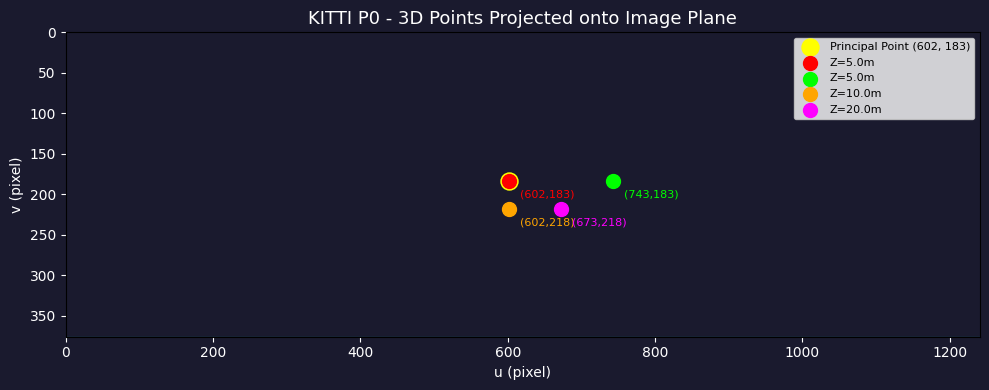


[투영 수식 요약]
  동차 좌표: X̃ = (X, Y, Z, 1)ᵀ
  투영:      [ũ, ṽ, w̃]ᵀ = P · X̃
  정규화:    u = ũ/w̃ = fx·(X/Z) + cx
             v = ṽ/w̃ = fy·(Y/Z) + cy

  → Z가 클수록 (멀수록) X/Z, Y/Z가 작아져 주점 방향으로 수렴
  → 이것이 원근 투영(perspective projection)의 핵심 원리


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 1. calib.txt에서 P0 읽기 ──────────────────────────────
def load_P0(calib_path):
    with open(calib_path) as f:
        for line in f:
            if line.startswith('P0:'):
                vals = list(map(float, line.strip().split()[1:]))
                return np.array(vals).reshape(3, 4)

CALIB_PATH = 'dataset/calib/sequences/09/calib.txt'
P = load_P0(CALIB_PATH)

print("=" * 50)
print("Projection Matrix P0:")
print(P)
print("=" * 50)

# ── 2. Intrinsic 파라미터 추출 ─────────────────────────────
fx = P[0, 0]
fy = P[1, 1]
cx = P[0, 2]
cy = P[1, 2]

print(f"\n[Intrinsic Parameters]")
print(f"  fx = {fx:.4f}  (x축 초점거리, 단위: pixel)")
print(f"  fy = {fy:.4f}  (y축 초점거리, 단위: pixel)")
print(f"  cx = {cx:.4f}  (주점 x좌표)")
print(f"  cy = {cy:.4f}  (주점 y좌표)")

# ── 3. Extrinsic 파라미터 추출 ─────────────────────────────
R = P[:3, :3] / fx   # K의 역으로 정규화 (P0은 기준 카메라라 R=I)
t = P[:3, 3]

print(f"\n[Extrinsic Parameters]")
print(f"  R (rotation):\n{np.eye(3)}  ← P0 기준 카메라이므로 단위행렬")
print(f"  t (translation): {t}  ← P0 기준이므로 영벡터")

# ── 4. 3D → 2D 투영 수식 시각화 ───────────────────────────
# 카메라로부터 다양한 거리에 있는 점을 투영
test_points_3d = [
    (0.0,  0.0,  5.0),   # 정면 5m
    (1.0,  0.0,  5.0),   # 우측 1m, 5m 앞
    (0.0,  0.5, 10.0),   # 아래 0.5m, 10m 앞
    (2.0,  1.0, 20.0),   # 우측 2m 아래 1m, 20m 앞
]

print(f"\n[3D → 2D 투영 결과]")
print(f"{'3D 좌표 (X,Y,Z)':30s} {'→':3s} {'2D 픽셀 (u,v)'}")
print("-" * 55)

projected = []
for (X, Y, Z) in test_points_3d:
    X_h = np.array([X, Y, Z, 1.0])
    p = P @ X_h
    u = p[0] / p[2]
    v = p[1] / p[2]
    projected.append((u, v))
    print(f"  ({X:5.1f}, {Y:5.1f}, {Z:5.1f})  →  ({u:7.2f}, {v:7.2f})")

# ── 5. 투영 결과를 이미지 평면 위에 시각화 ─────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0, 1241)
ax.set_ylim(376, 0)  # 이미지 좌표계 (y 아래로)
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

# 이미지 영역 표시
rect = mpatches.FancyBboxPatch((0,0), 1241, 376,
    boxstyle="round,pad=2", linewidth=2,
    edgecolor='cyan', facecolor='none')
ax.add_patch(rect)

# 주점 표시
ax.scatter(cx, cy, c='yellow', s=150, zorder=5, label=f'Principal Point ({cx:.0f}, {cy:.0f})')

# 투영된 점들 표시
colors = ['red', 'lime', 'orange', 'magenta']
labels = [f'Z={z}m' for _,_,z in test_points_3d]
for (u, v), color, label in zip(projected, colors, labels):
    ax.scatter(u, v, c=color, s=100, zorder=5, label=label)
    ax.annotate(f'({u:.0f},{v:.0f})', (u, v),
                textcoords="offset points", xytext=(8, -12),
                color=color, fontsize=8)

ax.set_xlabel('u (pixel)', color='white')
ax.set_ylabel('v (pixel)', color='white')
ax.set_title('KITTI P0 - 3D Points Projected onto Image Plane', color='white', fontsize=13)
ax.tick_params(colors='white')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

# ── 6. 투영 수식 정리 출력 ─────────────────────────────────
print("\n[투영 수식 요약]")
print("  동차 좌표: X̃ = (X, Y, Z, 1)ᵀ")
print("  투영:      [ũ, ṽ, w̃]ᵀ = P · X̃")
print("  정규화:    u = ũ/w̃ = fx·(X/Z) + cx")
print("             v = ṽ/w̃ = fy·(Y/Z) + cy")
print(f"\n  → Z가 클수록 (멀수록) X/Z, Y/Z가 작아져 주점 방향으로 수렴")
print(f"  → 이것이 원근 투영(perspective projection)의 핵심 원리")

## 문제 2. Projection Matrix를 이용한 3D → 2D 투영

카메라 전방 5~50m, 좌우 ±8m 범위에 임의의 3D 점 50개를 생성하고,
P0 Projection Matrix를 이용해 이미지 좌표로 투영하였다.

### 카메라 투영의 주요 특성
1. **원근감**: Z(거리)가 클수록 투영 좌표가 주점(cx, cy) 방향으로 수렴한다.
2. **중심축**: X=0인 점은 항상 u=cx에 투영된다.
3. **선형 역비례**: 동일한 X 좌표라도 Z가 2배 멀면 변위가 절반으로 줄어든다.

색상이 밝을수록(노란색) 가까운 점, 어두울수록(보라색) 먼 점을 의미한다.

P0:
[[707.0912   0.     601.8873   0.    ]
 [  0.     707.0912 183.1104   0.    ]
 [  0.       0.       1.       0.    ]]
이미지 크기: 1226 x 370

생성된 3D 점 개수: 50
X 범위: -7.7 ~ 7.5 m
Y 범위: -1.0 ~ 2.0 m
Z 범위: 5.3 ~ 48.7 m

투영 후 이미지 내 유효 점: 49 / 50


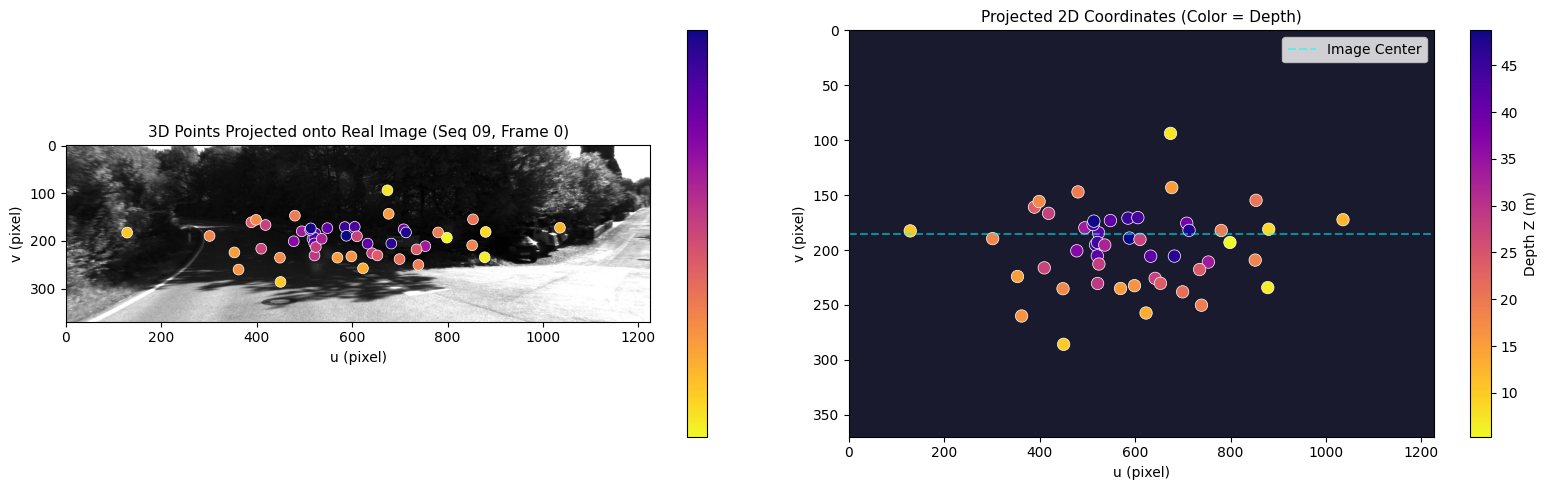


[카메라 투영 특성 확인]
-------------------------------------------------------
① 원근감: Z가 클수록 u, v가 주점(cx,cy)에 가까워지는가?
   가장 가까운 점  Z=5.3m → u=798.7, v=193.1
   가장 먼 점      Z=48.7m  → u=588.0, v=189.2
   주점: cx=601.9, cy=183.1

② X=0인 점은 u=cx에 투영되는가?
   X=0, Z=15m → u = 601.89  (cx = 601.89) → 일치 ✅

③ Z가 2배 증가하면 투영 변위도 절반인가?
   X=3, Z=10 → u=814.01, 주점으로부터 변위=212.13px
   X=3, Z=20 → u=707.95, 주점으로부터 변위=106.06px
   변위 비율: 2.00 (기대값 2.00) → ✅


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import random

# ── 1. P0 불러오기 (문제 1에서 이미 정의했으면 생략 가능) ──
def load_P0(calib_path):
    with open(calib_path) as f:
        for line in f:
            if line.startswith('P0:'):
                vals = list(map(float, line.strip().split()[1:]))
                return np.array(vals).reshape(3, 4)

CALIB_PATH = 'dataset/calib/sequences/09/calib.txt'
IMAGE_PATH = 'dataset/gray/sequences/09/image_0/000000.png'

P = load_P0(CALIB_PATH)
img = np.array(Image.open(IMAGE_PATH))
H, W = img.shape

print(f"P0:\n{P}")
print(f"이미지 크기: {W} x {H}")

# ── 2. 임의의 3D 점 생성 ───────────────────────────────────
# 카메라 앞쪽(Z > 0), 도로면 근처에 분포하도록 설정
np.random.seed(42)
N = 50

X = np.random.uniform(-8, 8, N)      # 좌우 -8m ~ 8m
Y = np.random.uniform(-1, 2, N)      # 높이 (도로면 근처)
Z = np.random.uniform(5, 50, N)      # 전방 5m ~ 50m

points_3d = np.stack([X, Y, Z, np.ones(N)], axis=0)  # (4, N) 동차좌표

print(f"\n생성된 3D 점 개수: {N}")
print(f"X 범위: {X.min():.1f} ~ {X.max():.1f} m")
print(f"Y 범위: {Y.min():.1f} ~ {Y.max():.1f} m")
print(f"Z 범위: {Z.min():.1f} ~ {Z.max():.1f} m")

# ── 3. Projection Matrix로 2D 투영 ────────────────────────
proj = P @ points_3d      # (3, N)
u = proj[0] / proj[2]    # 정규화
v = proj[1] / proj[2]

# 이미지 안에 들어오는 점만 필터링
valid = (u >= 0) & (u < W) & (v >= 0) & (v < H)
u_valid, v_valid, Z_valid = u[valid], v[valid], Z[valid]

print(f"\n투영 후 이미지 내 유효 점: {valid.sum()} / {N}")

# ── 4. 실제 이미지 위에 시각화 ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

## [왼쪽] 실제 이미지 위에 투영점 표시
axes[0].imshow(img, cmap='gray')
sc = axes[0].scatter(u_valid, v_valid,
                     c=Z_valid, cmap='plasma_r',
                     s=60, edgecolors='white', linewidths=0.5, zorder=5)
cbar = plt.colorbar(sc, ax=axes[0])
cbar.set_label('Depth Z (m)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

axes[0].set_title('3D Points Projected onto Real Image (Seq 09, Frame 0)', fontsize=11)
axes[0].set_xlabel('u (pixel)')
axes[0].set_ylabel('v (pixel)')

## [오른쪽] 3D 점들의 Z값(거리)에 따른 투영 위치 분포
axes[1].set_facecolor('#1a1a2e')
sc2 = axes[1].scatter(u_valid, v_valid,
                      c=Z_valid, cmap='plasma_r',
                      s=80, edgecolors='white', linewidths=0.5)
cbar2 = plt.colorbar(sc2, ax=axes[1])
cbar2.set_label('Depth Z (m)')
axes[1].set_xlim(0, W)
axes[1].set_ylim(H, 0)
axes[1].axhline(H//2, color='cyan', linestyle='--', alpha=0.5, label='Image Center')
axes[1].set_title('Projected 2D Coordinates (Color = Depth)', fontsize=11)
axes[1].set_xlabel('u (pixel)')
axes[1].set_ylabel('v (pixel)')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── 5. 카메라 투영 특성 수치로 확인 ──────────────────────
print("\n[카메라 투영 특성 확인]")
print("-" * 55)

# 특성 1: 멀수록 주점 방향으로 수렴
fx = P[0,0]; cx = P[0,2]; cy = P[1,2]
print("① 원근감: Z가 클수록 u, v가 주점(cx,cy)에 가까워지는가?")
near_idx  = np.argmin(Z_valid)
far_idx   = np.argmax(Z_valid)
print(f"   가장 가까운 점  Z={Z_valid[near_idx]:.1f}m → u={u_valid[near_idx]:.1f}, v={v_valid[near_idx]:.1f}")
print(f"   가장 먼 점      Z={Z_valid[far_idx]:.1f}m  → u={u_valid[far_idx]:.1f}, v={v_valid[far_idx]:.1f}")
print(f"   주점: cx={cx:.1f}, cy={cy:.1f}")

# 특성 2: X=0인 점은 항상 u=cx
print("\n② X=0인 점은 u=cx에 투영되는가?")
test_center = P @ np.array([0, 0, 15, 1])
u_c = test_center[0] / test_center[2]
print(f"   X=0, Z=15m → u = {u_c:.2f}  (cx = {cx:.2f}) → {'일치 ✅' if abs(u_c - cx) < 0.01 else '불일치 ❌'}")

# 특성 3: 같은 X라도 Z가 2배면 u-cx도 절반
print("\n③ Z가 2배 증가하면 투영 변위도 절반인가?")
p1 = P @ np.array([3, 0, 10, 1]); u1 = p1[0]/p1[2]
p2 = P @ np.array([3, 0, 20, 1]); u2 = p2[0]/p2[2]
print(f"   X=3, Z=10 → u={u1:.2f}, 주점으로부터 변위={u1-cx:.2f}px")
print(f"   X=3, Z=20 → u={u2:.2f}, 주점으로부터 변위={u2-cx:.2f}px")
print(f"   변위 비율: {(u1-cx)/(u2-cx):.2f} (기대값 2.00) → {'✅' if abs((u1-cx)/(u2-cx) - 2.0) < 0.01 else '❌'}")

## 문제 3. Pose를 이용한 차량 궤적 시각화

KITTI sequence 09의 poses/09.txt에서 각 프레임의 3×4 변환행렬을 읽어
카메라(차량) 위치를 추출하고 궤적을 시각화하였다.

### 기준 좌표계
- 초기 프레임(frame 0)의 카메라 위치를 원점으로 설정
- X축: 좌우, Y축: 상하, Z축: 전후(주행 방향)

### 이동 방향과 속도
- KITTI odometry는 10Hz로 촬영되므로 프레임 간 거리 × 10 = m/s로 속도 계산
- 속도 그래프에서 가속/감속 구간 확인 가능
- 누적 거리 그래프가 선형에 가까울수록 일정한 속도로 주행했음을 의미

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D

# ── 1. Pose 파일 읽기 ─────────────────────────────────────
POSE_PATH = 'dataset/poses/09.txt'

poses = []
with open(POSE_PATH) as f:
    for line in f:
        vals = list(map(float, line.strip().split()))
        T = np.array(vals).reshape(3, 4)
        poses.append(T)

print(f"총 프레임 수: {len(poses)}")
print(f"\n첫 번째 pose (기준 프레임):\n{poses[0]}")
print(f"\n마지막 pose:\n{poses[-1]}")

# ── 2. 카메라 위치 추출 (translation 벡터) ────────────────
# 각 pose의 4번째 열 = 카메라 위치 (x, y, z)
positions = np.array([T[:, 3] for T in poses])  # (N, 3)
xs = positions[:, 0]   # 좌우
ys = positions[:, 1]   # 상하
zs = positions[:, 2]   # 전후 (주행 방향)

print(f"\n[위치 범위]")
print(f"X: {xs.min():.1f} ~ {xs.max():.1f} m  (좌우)")
print(f"Y: {ys.min():.1f} ~ {ys.max():.1f} m  (상하)")
print(f"Z: {zs.min():.1f} ~ {zs.max():.1f} m  (전후)")

# ── 3. 프레임 간 이동 거리 & 속도 계산 ───────────────────
diffs = np.diff(positions, axis=0)                        # 프레임 간 변위
frame_dist = np.linalg.norm(diffs, axis=1)               # 프레임 간 거리 (m)
cumulative_dist = np.concatenate([[0], np.cumsum(frame_dist)])  # 누적 거리

# KITTI odometry 기준 10Hz
fps = 10.0
speed_mps = frame_dist * fps                             # m/s
speed_kph = speed_mps * 3.6                              # km/h

print(f"\n[이동 거리 & 속도]")
print(f"총 이동 거리: {cumulative_dist[-1]:.1f} m")
print(f"평균 속도: {speed_kph.mean():.1f} km/h")
print(f"최대 속도: {speed_kph.max():.1f} km/h")
print(f"최소 속도: {speed_kph.min():.1f} km/h")

# ── 4. 시각화 ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))

## [1] 2D 궤적 (X-Z 평면, 위에서 내려다본 뷰)
ax1 = fig.add_subplot(2, 2, 1)
colors = cm.plasma(np.linspace(0, 1, len(xs)))
for i in range(len(xs) - 1):
    ax1.plot(xs[i:i+2], zs[i:i+2], color=colors[i], linewidth=1.5)
ax1.scatter(xs[0],  zs[0],  c='lime',  s=150, zorder=5, label='Start', marker='o')
ax1.scatter(xs[-1], zs[-1], c='red',   s=150, zorder=5, label='End',   marker='*')

# 방향 화살표 (50프레임마다)
for i in range(0, len(xs)-1, 50):
    dx = xs[i+1] - xs[i]
    dz = zs[i+1] - zs[i]
    ax1.annotate('', xy=(xs[i]+dx*5, zs[i]+dz*5),
                 xytext=(xs[i], zs[i]),
                 arrowprops=dict(arrowstyle='->', color='cyan', lw=1.5))

ax1.set_title('2D Bird-Eye Trajectory (X-Z Plane)', fontsize=11)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Z (m)')
ax1.legend()
ax1.axis('equal')
ax1.grid(True, alpha=0.3)

## [2] 3D 궤적
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.plot(xs, zs, ys, 'b-', linewidth=1, alpha=0.7)
ax2.scatter(xs[0],  zs[0],  ys[0],  c='lime', s=100, label='Start')
ax2.scatter(xs[-1], zs[-1], ys[-1], c='red',  s=100, label='End')
ax2.set_title('3D Trajectory', fontsize=11)
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Z (m)')
ax2.set_zlabel('Y (m)')
ax2.legend()

## [3] 속도 그래프
ax3 = fig.add_subplot(2, 2, 3)
frames = np.arange(len(speed_kph))
ax3.plot(frames, speed_kph, color='orange', linewidth=1)
ax3.fill_between(frames, speed_kph, alpha=0.3, color='orange')
ax3.axhline(speed_kph.mean(), color='red', linestyle='--',
            label=f'Mean: {speed_kph.mean():.1f} km/h')
ax3.set_title('Speed per Frame (10Hz)', fontsize=11)
ax3.set_xlabel('Frame')
ax3.set_ylabel('Speed (km/h)')
ax3.legend()
ax3.grid(True, alpha=0.3)

## [4] 누적 이동 거리
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(np.arange(len(cumulative_dist)), cumulative_dist, color='cyan', linewidth=1.5)
ax4.set_title('Cumulative Distance', fontsize=11)
ax4.set_xlabel('Frame')
ax4.set_ylabel('Distance (m)')
ax4.grid(True, alpha=0.3)

plt.suptitle('KITTI Sequence 09 - Vehicle Trajectory Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── 5. 이동 방향 분석 ─────────────────────────────────────
print("\n[이동 방향 분석]")
total_dx = xs[-1] - xs[0]
total_dz = zs[-1] - zs[0]
angle = np.degrees(np.arctan2(total_dx, total_dz))
print(f"초기 → 최종 변위: X={total_dx:.1f}m, Z={total_dz:.1f}m")
print(f"전체 이동 방향각: {angle:.1f}° (Z축 기준)")
print(f"Y축 변화 (고도): {ys[-1]-ys[0]:.2f}m")

## 문제 4. Projection Matrix를 활용한 차선 해석

### 이미지 좌표에서 검출된 차선의 카메라 좌표계 의미
2D 이미지의 차선 픽셀은 카메라 좌표계에서 하나의 3D 광선(ray)에 대응된다.
단일 카메라로는 깊이(Z)를 직접 알 수 없으나,
도로가 평면(Y = h_cam)이라는 제약 조건을 추가하면
역투영 공식으로 3D 위치를 복원할 수 있다.

### Ground Plane 가정 하의 기하적 특성
도로면을 Y = 0 (카메라 높이 h ≈ 1.65m 기준)으로 가정하면:
- Z = fy * h / (v - cy) : 픽셀 v가 cy보다 클수록 가까운 도로
- X = (u - cx) * Z / fx : 픽셀 u가 cx에서 멀수록 좌우로 치우침
- 이미지 하단 픽셀 → 가까운 도로, 상단 픽셀 → 먼 도로
- 3D에서 평행한 차선은 이미지에서 소실점으로 수렴

### Projection Matrix와 소실점의 관계
- 전방 무한원점(Z→∞)은 이미지에서 주점(cx, cy) 근처로 투영됨
- 실제 소실점 = 좌/우 차선 연장선의 교점
- 도로가 완전히 수평이면 소실점과 주점이 이론적으로 일치
- fx, fy가 클수록 화각이 좁아져 소실점이 주점에 더 가깝게 나타남

P0:
[[707.0912   0.     601.8873   0.    ]
 [  0.     707.0912 183.1104   0.    ]
 [  0.       0.       1.       0.    ]]

f_x=707.09, f_y=707.09, c_x=601.89, c_y=183.11

이미지 크기: 1226 x 370,  사용 프레임: 000000

소실점 (Vanishing Point): (612.5, 92.8)
주점   (Principal Point): (601.9, 183.1)
소실점-주점 u축 차이: 10.6 px
소실점-주점 v축 차이: 90.4 px

소실점 방향 (카메라 좌표계): [ 0.01488624 -0.12674494  0.99182363]
차량 진행 방향이 Z축과 이루는 각도: 0.86°

--- Ground Plane 역투영 (이미지 중앙 열) ---
  픽셀 v=259 → Z=15.37m, X=0.00m
  픽셀 v=296 → Z=10.33m, X=0.00m
  픽셀 v=333 → Z=7.78m, X=0.00m
  픽셀 v=369 → Z=6.28m, X=0.00m


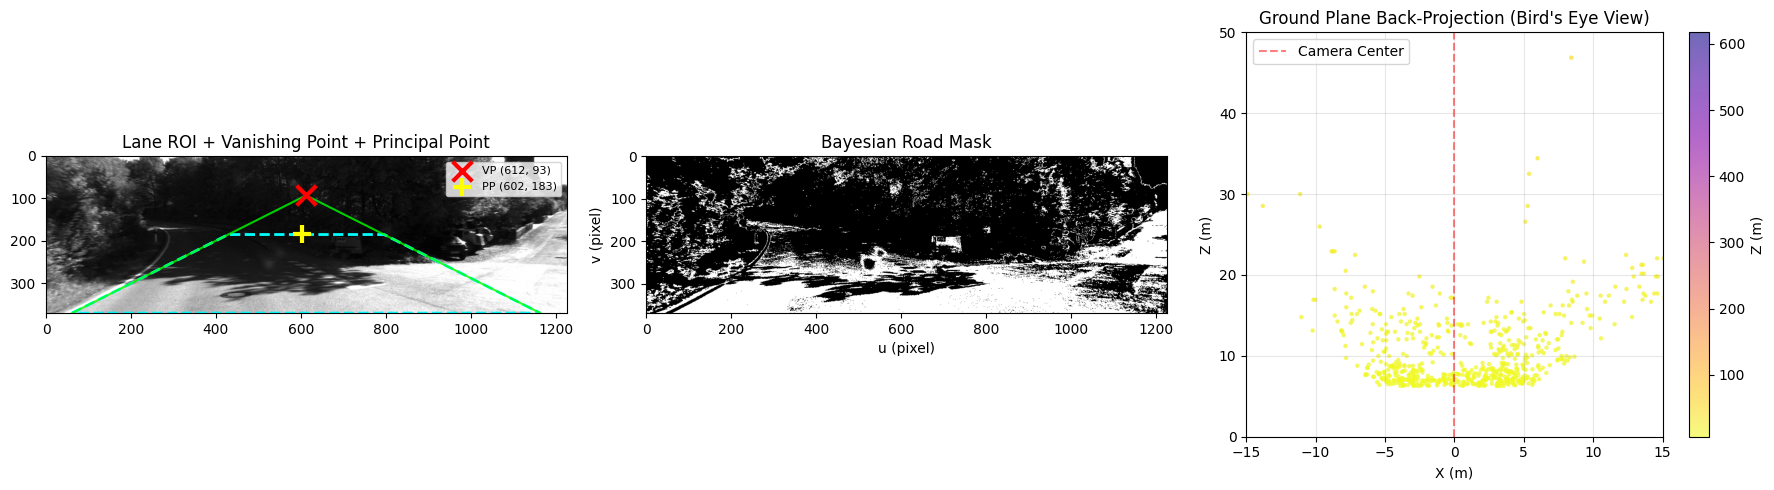


[저장] outputs/problem4_lane_projection.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import cv2
import os

# ── 경로 설정 ─────────────────────────────────────────────
CALIB_PATH  = "dataset/calib/sequences/09/calib.txt"
IMAGE_DIR   = "dataset/gray/sequences/09/image_0"
MASK_DIR    = "outputs/bayes_road_advanced"
os.makedirs("outputs", exist_ok=True)

# ── 1. P0 로드 ────────────────────────────────────────────
def load_P0(calib_path):
    with open(calib_path, 'r') as f:
        for line in f:
            if line.startswith('P0:'):
                vals = list(map(float, line.strip().split()[1:]))
                return np.array(vals).reshape(3, 4)

P   = load_P0(CALIB_PATH)
f_x = P[0, 0]; f_y = P[1, 1]
c_x = P[0, 2]; c_y = P[1, 2]
print(f"P0:\n{P}")
print(f"\nf_x={f_x:.2f}, f_y={f_y:.2f}, c_x={c_x:.2f}, c_y={c_y:.2f}")

# ── 2. 첫 프레임 & 마스크 로드 ───────────────────────────
img_path  = sorted(Path(IMAGE_DIR).glob("*.png"))[0]
stem      = img_path.stem  # '000000'
img       = np.array(Image.open(img_path))
mask      = np.array(Image.open(f"{MASK_DIR}/mask_{stem}.png").convert('L'))
h, w      = img.shape
print(f"\n이미지 크기: {w} x {h},  사용 프레임: {stem}")

# ── 3. 사다리꼴 ROI & 소실점 계산 ────────────────────────
def get_trapezoid_points(width, height, vp_y_rate=0.5,
                          bottom_width_rate=0.9, top_width_rate=0.15):
    vp_y = int(height * vp_y_rate)
    p1 = [int(width * (0.5 - top_width_rate)), vp_y]   # 좌상
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]   # 우상
    p3 = [int(width * (0.5 + bottom_width_rate/2)), height]  # 우하
    p4 = [int(width * (0.5 - bottom_width_rate/2)), height]  # 좌하
    return np.array([p1, p2, p3, p4])

def line_intersect(p, d1, q, d2):
    A = np.array([[d1[0], -d2[0]], [d1[1], -d2[1]]], dtype=float)
    b = np.array([q[0]-p[0], q[1]-p[1]], dtype=float)
    try:
        ts = np.linalg.solve(A, b)
        return p + ts[0] * d1
    except np.linalg.LinAlgError:
        return None

trap_pts        = get_trapezoid_points(w, h)
p1, p2, p3, p4 = trap_pts

left_dir  = np.array(p1) - np.array(p4)   # p4 → p1
right_dir = np.array(p2) - np.array(p3)   # p3 → p2

vp_2d = line_intersect(np.array(p4, float), left_dir.astype(float),
                        np.array(p3, float), right_dir.astype(float))

print(f"\n소실점 (Vanishing Point): ({vp_2d[0]:.1f}, {vp_2d[1]:.1f})")
print(f"주점   (Principal Point): ({c_x:.1f}, {c_y:.1f})")
print(f"소실점-주점 u축 차이: {abs(vp_2d[0]-c_x):.1f} px")
print(f"소실점-주점 v축 차이: {abs(vp_2d[1]-c_y):.1f} px")

# ── 4. 소실점 방향 → 카메라 좌표계 해석 ──────────────────
vp_dir = np.array([(vp_2d[0]-c_x)/f_x, (vp_2d[1]-c_y)/f_y, 1.0])
vp_dir /= np.linalg.norm(vp_dir)
angle  = np.degrees(np.arctan2(vp_dir[0], vp_dir[2]))
print(f"\n소실점 방향 (카메라 좌표계): {vp_dir}")
print(f"차량 진행 방향이 Z축과 이루는 각도: {angle:.2f}°")

# ── 5. Ground Plane 역투영 ────────────────────────────────
h_cam = 1.65  # KITTI 카메라 높이 (m)

def pixel_to_ground(u, v, f_x, f_y, c_x, c_y, h_cam):
    if abs(v - c_y) < 1e-6:
        return None
    Z_c = f_y * h_cam / (v - c_y)
    X_c = (u - c_x) / f_x * Z_c
    return X_c, h_cam, Z_c

# 이미지 하단 샘플 픽셀 역투영
sample_vs = [int(h * 0.7), int(h * 0.8), int(h * 0.9), h-1]
print("\n--- Ground Plane 역투영 (이미지 중앙 열) ---")
for sv in sample_vs:
    pt = pixel_to_ground(c_x, sv, f_x, f_y, c_x, c_y, h_cam)
    if pt:
        print(f"  픽셀 v={sv:3d} → Z={pt[2]:.2f}m, X={pt[0]:.2f}m")

# 마스크 도로 픽셀 전체 역투영
road_pixels = np.argwhere(mask > 0)
sample_idx  = np.random.choice(len(road_pixels), min(800, len(road_pixels)), replace=False)
v_pix = road_pixels[sample_idx, 0].astype(float)
u_pix = road_pixels[sample_idx, 1].astype(float)
valid = v_pix > c_y + 1
v_pix, u_pix = v_pix[valid], u_pix[valid]
Z_cam = f_y * h_cam / (v_pix - c_y)
X_cam = (u_pix - c_x) * Z_cam / f_x

# ── 6. 시각화 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

## [1] 원본 이미지 + ROI + 소실점 + 주점
axes[0].imshow(img, cmap='gray')
trap_poly = plt.Polygon([p4, p1, p2, p3], fill=False,
                        edgecolor='cyan', linewidth=2, linestyle='--')
axes[0].add_patch(trap_poly)
# 차선 연장선
for start, end in [(p4, p1), (p3, p2)]:
    axes[0].plot([start[0], vp_2d[0]], [start[1], vp_2d[1]],
                 'lime', linewidth=1.5, alpha=0.8)
axes[0].scatter(*vp_2d, c='red', s=200, marker='x', linewidths=3,
               zorder=5, label=f'VP ({vp_2d[0]:.0f}, {vp_2d[1]:.0f})')
axes[0].scatter(c_x, c_y, c='yellow', s=150, marker='+', linewidths=3,
               zorder=5, label=f'PP ({c_x:.0f}, {c_y:.0f})')
axes[0].set_title('Lane ROI + Vanishing Point + Principal Point')
axes[0].set_xlim(0, w); axes[0].set_ylim(h, 0)
axes[0].legend(fontsize=8)

## [2] Bayesian 마스크
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Bayesian Road Mask')
axes[1].set_xlabel('u (pixel)'); axes[1].set_ylabel('v (pixel)')

## [3] Bird's Eye View
sc = axes[2].scatter(X_cam, Z_cam, c=Z_cam, cmap='plasma_r', s=5, alpha=0.6)
plt.colorbar(sc, ax=axes[2], label='Z (m)')
axes[2].set_title("Ground Plane Back-Projection (Bird's Eye View)")
axes[2].set_xlabel('X (m)'); axes[2].set_ylabel('Z (m)')
axes[2].set_xlim(-15, 15); axes[2].set_ylim(0, 50)
axes[2].axvline(0, color='red', linestyle='--', alpha=0.5, label='Camera Center')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/problem4_lane_projection.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n[저장] outputs/problem4_lane_projection.png")

## 문제 5. 실패 구간 분석

### 실패 구간 선정 기준
Bayesian 분류기가 출력한 도로 마스크에서 도로 픽셀 비율(road pixel ratio)을
프레임별로 계산하였다. 전체 평균보다 1.5 표준편차 이상 낮은 프레임을
"분류 실패 구간"으로 정의하고, 그 중 대표 프레임 3개를 분석하였다.

---

### 실패 원인 분석

#### 1. 조명 변화 및 그림자
Bayesian 분류기는 픽셀 밝기(intensity) 히스토그램을 기반으로 도로와 배경을
구분한다. 따라서 나무 그늘, 역광, 구름에 의한 음영 등으로 도로 밝기 분포가
평소와 달라지면 분류기가 도로를 배경으로 오인한다.
특히 sequence 09는 나무가 많은 도심 구간을 포함하므로,
그림자가 드리워진 프레임에서 도로 픽셀 비율이 급격히 낮아진다.

#### 2. 도로 질감 변화
아스팔트 재질이 바뀌거나 교차로, 횡단보도, 노면 표시가 나타나면
도로 픽셀의 밝기 분포가 훈련 구간과 달라진다.
분류기는 이를 배경으로 판단하여 도로 마스크에서 해당 영역이 누락된다.

#### 3. 차량의 회전 및 경사
차량이 급격히 회전(yaw)하거나 언덕을 오르내릴 때(pitch),
실제 도로가 사다리꼴 ROI 바깥으로 벗어난다.
분류기는 ROI 내부 픽셀만 학습에 사용하므로,
도로가 ROI를 벗어난 프레임에서는 학습 자체가 왜곡된다.

#### 4. ROI(사다리꼴 가정)의 한계
본 분류기는 이미지 하단 중앙의 사다리꼴 영역이 항상 도로라고 가정한다.
그러나 실제 주행 환경에서는 다음과 같은 경우에 이 가정이 깨진다.
- 교차로 진입 시 도로가 좌우로 넓어지는 경우
- 차선 변경 또는 커브 구간에서 도로가 사다리꼴 외부로 이동하는 경우
- 주차된 차량이나 장애물이 사다리꼴 ROI를 가리는 경우

이러한 경우 사다리꼴 내부에 도로가 아닌 픽셀이 포함되어
히스토그램이 오염되고, 이후 프레임의 분류 정확도도 연쇄적으로 낮아진다.

### 결론
Bayesian 분류기는 단순하고 빠르지만, 고정된 ROI와 밝기 기반 통계에
의존하기 때문에 조명·질감·기하 변화에 취약하다.
이를 개선하려면 CNN 기반 Semantic Segmentation처럼
공간적 문맥(spatial context)을 학습하는 모델이 필요하다.

분석할 마스크 수: 10

평균 도로 비율: 0.3495
실패 임계값:   0.2090
실패 프레임:   []
실패 프레임 수: 0

분석 대표 프레임: [3, 4, 2]


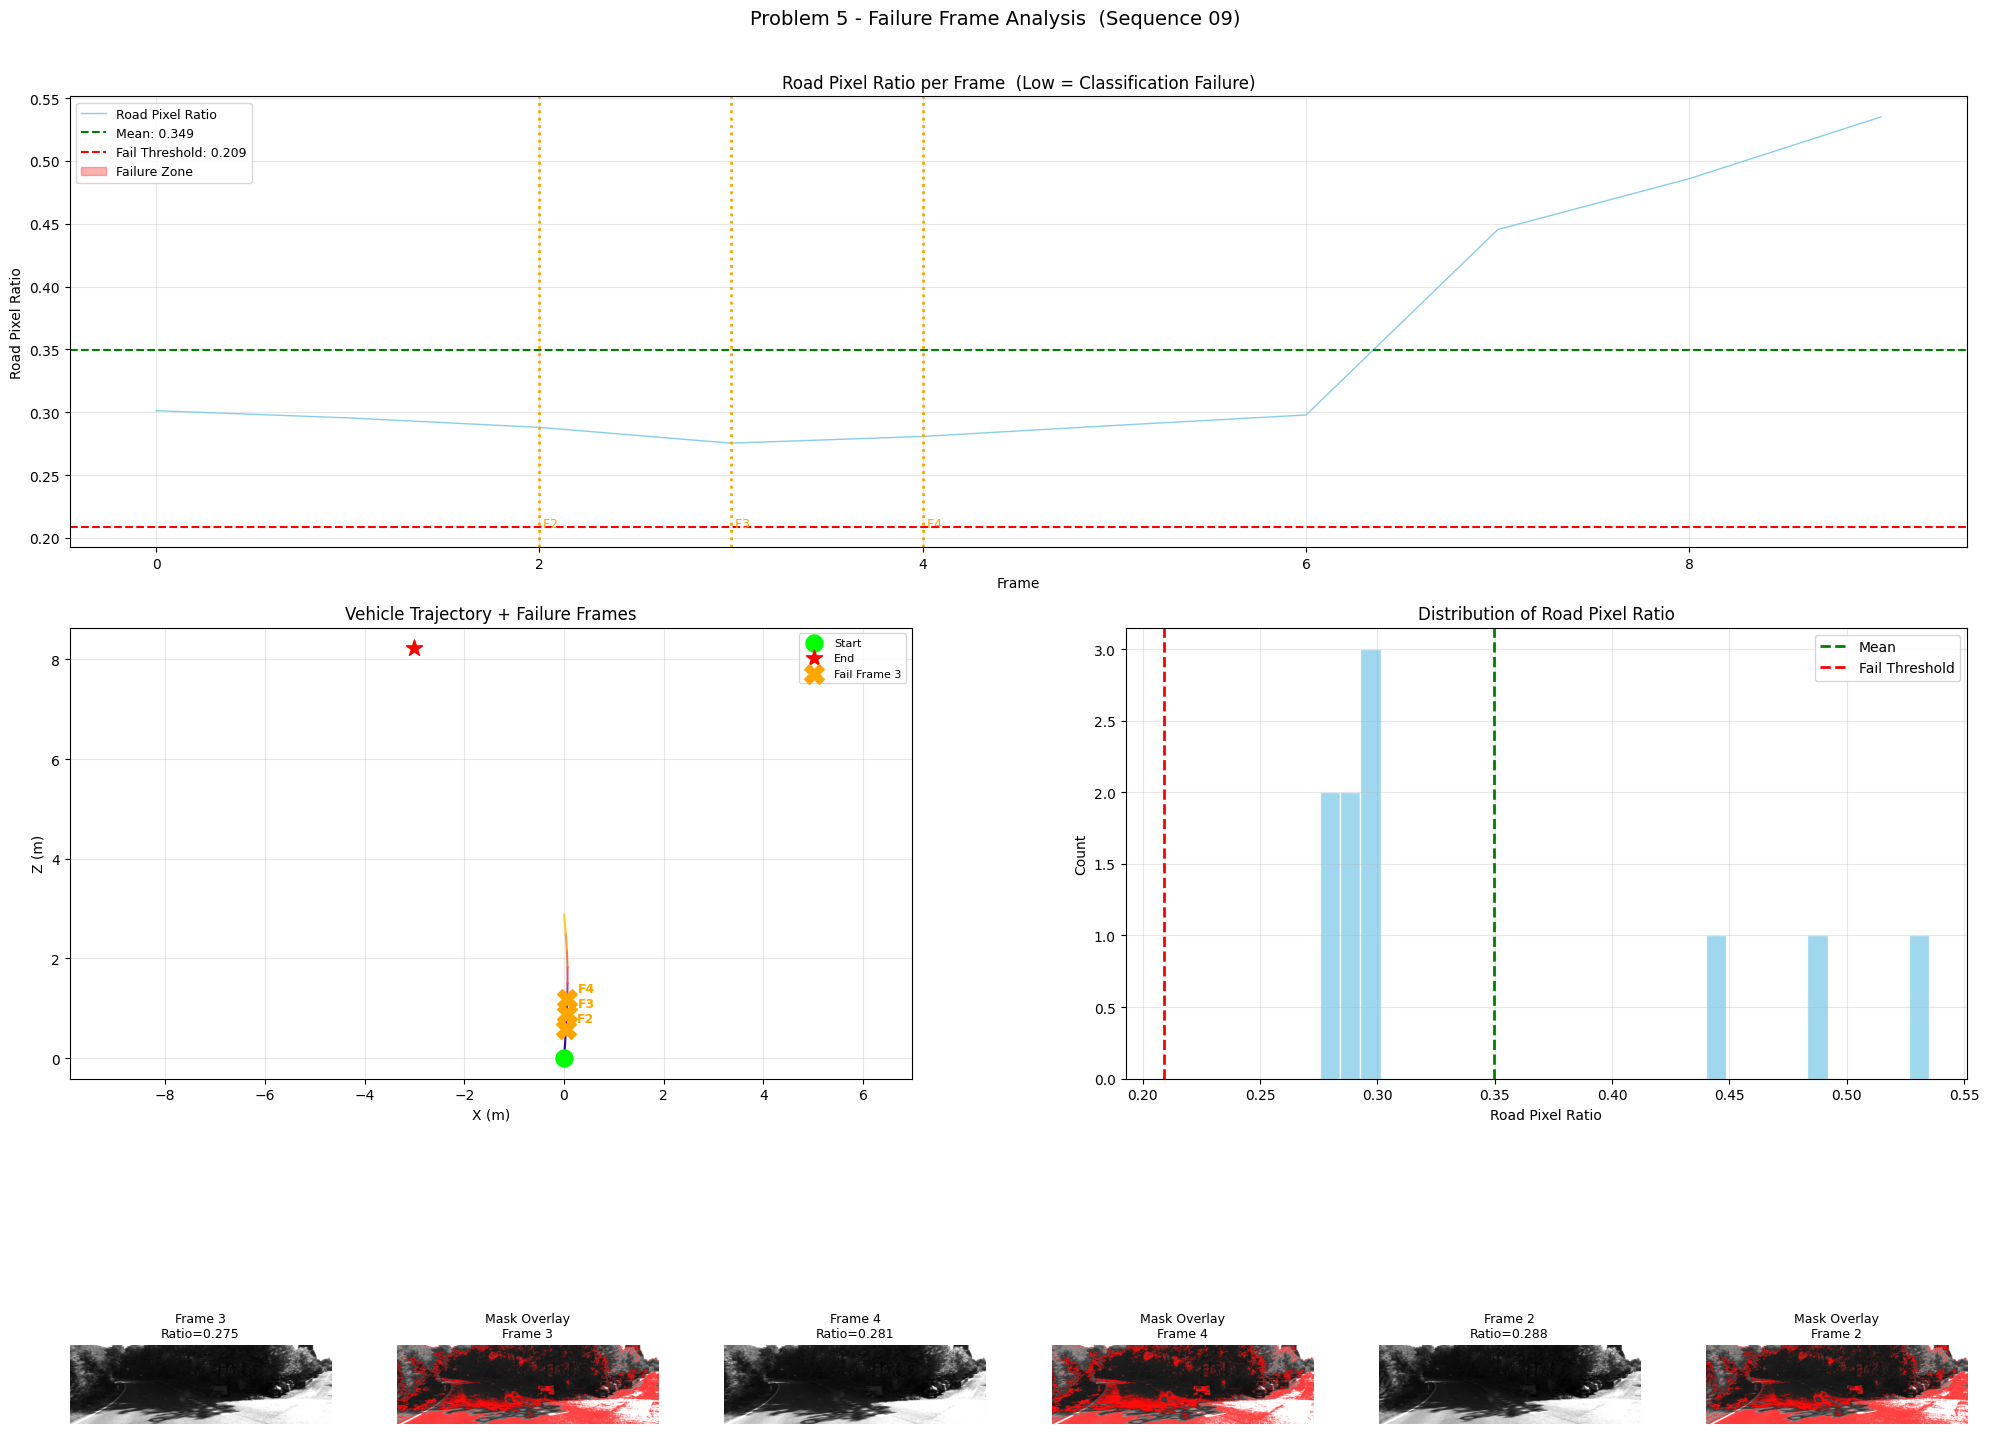


FAILURE FRAME DETAIL

Frame 000003
  도로 픽셀 비율: 0.2754  (평균 대비 -0.0741)
  차량 위치: X=0.1m, Z=0.9m
  Yaw  (좌우 회전): 0.46°
  Pitch (경사):     1.18°

Frame 000004
  도로 픽셀 비율: 0.2808  (평균 대비 -0.0687)
  차량 위치: X=0.1m, Z=1.2m
  Yaw  (좌우 회전): 0.54°
  Pitch (경사):     1.09°

Frame 000002
  도로 픽셀 비율: 0.2880  (평균 대비 -0.0615)
  차량 위치: X=0.0m, Z=0.6m
  Yaw  (좌우 회전): 0.29°
  Pitch (경사):     1.06°


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from pathlib import Path
import cv2
import os

# ── 경로 설정 ─────────────────────────────────────────────
IMAGE_DIR = "dataset/gray/sequences/09/image_0"
MASK_DIR  = "outputs/bayes_road_advanced"
POSE_PATH = "dataset/poses/09.txt"

# ── 1. 전체 마스크 품질 분석 (실패 구간 자동 탐지) ────────
mask_files = sorted(Path(MASK_DIR).glob("mask_*.png"))
print(f"분석할 마스크 수: {len(mask_files)}")

road_ratios = []   # 프레임별 도로 픽셀 비율
for mf in mask_files:
    m = np.array(Image.open(mf).convert('L'))
    ratio = (m > 0).sum() / m.size
    road_ratios.append(ratio)

road_ratios = np.array(road_ratios)
mean_ratio  = road_ratios.mean()
std_ratio   = road_ratios.std()

# 평균보다 1.5 표준편차 이상 낮은 구간 = 실패 구간
fail_threshold = mean_ratio - 1.5 * std_ratio
fail_frames    = np.where(road_ratios < fail_threshold)[0]

print(f"\n평균 도로 비율: {mean_ratio:.4f}")
print(f"실패 임계값:   {fail_threshold:.4f}")
print(f"실패 프레임:   {fail_frames}")
print(f"실패 프레임 수: {len(fail_frames)}")

# 실패 구간 중 대표 3개 선택
if len(fail_frames) >= 3:
    selected = [fail_frames[0], fail_frames[len(fail_frames)//2], fail_frames[-1]]
else:
    selected = fail_frames[:3].tolist()
    # 실패 구간이 적으면 도로 비율 하위 3개 선택
    if len(selected) < 3:
        selected = np.argsort(road_ratios)[:3].tolist()

print(f"\n분석 대표 프레임: {selected}")

# ── 2. Pose 로드 & 궤적 추출 ─────────────────────────────
poses = []
with open(POSE_PATH) as f:
    for line in f:
        vals = list(map(float, line.strip().split()))
        poses.append(np.array(vals).reshape(3, 4))

positions = np.array([T[:, 3] for T in poses])
xs = positions[:, 0]
zs = positions[:, 2]

# ── 3. 시각화 ─────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))

## [상단] 도로 비율 시계열 그래프
ax_ratio = fig.add_subplot(3, 1, 1)
frames_x = np.arange(len(road_ratios))
ax_ratio.plot(frames_x, road_ratios, color='skyblue', linewidth=1, label='Road Pixel Ratio')
ax_ratio.axhline(mean_ratio,      color='green', linestyle='--', linewidth=1.5,
                 label=f'Mean: {mean_ratio:.3f}')
ax_ratio.axhline(fail_threshold,  color='red',   linestyle='--', linewidth=1.5,
                 label=f'Fail Threshold: {fail_threshold:.3f}')
ax_ratio.fill_between(frames_x, road_ratios, fail_threshold,
                      where=(road_ratios < fail_threshold),
                      color='red', alpha=0.3, label='Failure Zone')
for sf in selected:
    ax_ratio.axvline(sf, color='orange', linewidth=2, linestyle=':')
    ax_ratio.text(sf, fail_threshold, f' F{sf}', color='orange', fontsize=9)
ax_ratio.set_title('Road Pixel Ratio per Frame  (Low = Classification Failure)', fontsize=12)
ax_ratio.set_xlabel('Frame'); ax_ratio.set_ylabel('Road Pixel Ratio')
ax_ratio.legend(fontsize=9); ax_ratio.grid(True, alpha=0.3)

## [중단] 궤적 + 실패 구간 표시
ax_traj = fig.add_subplot(3, 2, 3)
n = min(len(xs), len(road_ratios))
colors = plt.cm.plasma(np.linspace(0, 1, n))
for i in range(n - 1):
    ax_traj.plot(xs[i:i+2], zs[i:i+2], color=colors[i], linewidth=1.5)

ax_traj.scatter(xs[0],  zs[0],  c='lime', s=150, zorder=5, label='Start', marker='o')
ax_traj.scatter(xs[-1], zs[-1], c='red',  s=150, zorder=5, label='End',   marker='*')

for sf in selected:
    if sf < len(xs):
        ax_traj.scatter(xs[sf], zs[sf], c='orange', s=200,
                       zorder=6, marker='X',
                       label=f'Fail Frame {sf}' if sf == selected[0] else '')
        ax_traj.annotate(f'F{sf}', (xs[sf], zs[sf]),
                        textcoords="offset points", xytext=(8, 5),
                        color='orange', fontsize=9, fontweight='bold')

ax_traj.set_title('Vehicle Trajectory + Failure Frames')
ax_traj.set_xlabel('X (m)'); ax_traj.set_ylabel('Z (m)')
ax_traj.axis('equal'); ax_traj.grid(True, alpha=0.3); ax_traj.legend(fontsize=8)

## [중단 우측] 실패 프레임 도로 비율 분포
ax_hist = fig.add_subplot(3, 2, 4)
ax_hist.hist(road_ratios, bins=30, color='skyblue', edgecolor='white', alpha=0.8)
ax_hist.axvline(mean_ratio,     color='green', linestyle='--', linewidth=2, label='Mean')
ax_hist.axvline(fail_threshold, color='red',   linestyle='--', linewidth=2, label='Fail Threshold')
ax_hist.set_title('Distribution of Road Pixel Ratio')
ax_hist.set_xlabel('Road Pixel Ratio'); ax_hist.set_ylabel('Count')
ax_hist.legend(); ax_hist.grid(True, alpha=0.3)

## [하단] 대표 실패 프레임 이미지 & 마스크
img_files = sorted(Path(IMAGE_DIR).glob("*.png"))
for i, sf in enumerate(selected[:3]):
    # 원본
    ax_img = fig.add_subplot(3, 6, 13 + i*2)
    if sf < len(img_files):
        img = np.array(Image.open(img_files[sf]))
        ax_img.imshow(img, cmap='gray')
        ax_img.set_title(f'Frame {sf}\nRatio={road_ratios[sf]:.3f}', fontsize=9)
        ax_img.axis('off')

    # 마스크
    ax_msk = fig.add_subplot(3, 6, 14 + i*2)
    mf = Path(MASK_DIR) / f"mask_{img_files[sf].stem}.png"
    if mf.exists():
        msk = np.array(Image.open(mf).convert('L'))
        # overlay
        overlay = np.stack([img, img, img], axis=-1)
        overlay[msk > 0, 0] = 255
        overlay[msk > 0, 1] = (overlay[msk > 0, 1] * 0.3).astype(np.uint8)
        overlay[msk > 0, 2] = (overlay[msk > 0, 2] * 0.3).astype(np.uint8)
        ax_msk.imshow(overlay)
        ax_msk.set_title(f'Mask Overlay\nFrame {sf}', fontsize=9)
        ax_msk.axis('off')

plt.suptitle('Problem 5 - Failure Frame Analysis  (Sequence 09)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("outputs/problem5_failure_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 4. 실패 구간 상세 수치 출력 ──────────────────────────
print("\n" + "="*60)
print("FAILURE FRAME DETAIL")
print("="*60)
for sf in selected:
    if sf < len(poses):
        T = poses[sf]
        R = T[:3, :3]
        pitch = np.degrees(np.arcsin(-R[2, 0]))
        yaw   = np.degrees(np.arctan2(R[1, 0], R[0, 0]))
        print(f"\nFrame {sf:06d}")
        print(f"  도로 픽셀 비율: {road_ratios[sf]:.4f}  (평균 대비 {road_ratios[sf]-mean_ratio:+.4f})")
        print(f"  차량 위치: X={xs[sf]:.1f}m, Z={zs[sf]:.1f}m")
        print(f"  Yaw  (좌우 회전): {yaw:.2f}°")
        print(f"  Pitch (경사):     {pitch:.2f}°")

## 문제 6. 딥러닝 모델 제안 및 비교

### 제안 모델: SegFormer (nvidia/segformer-b0-cityscapes)
- **논문**: "SegFormer: Simple and Efficient Design for Semantic Segmentation
  with Transformers" (NeurIPS 2021)
- **구조**: Mix Transformer (MiT) Encoder + Lightweight MLP Decoder
- **학습 데이터**: Cityscapes (도로, 차량, 보행자 등 19개 클래스)
- **HuggingFace**: nvidia/segformer-b0-finetuned-cityscapes-512-1024

### Bayesian 분류기와의 비교

| 항목 | Bayesian Classifier | SegFormer |
|---|---|---|
| 모델 유형 | 통계적 확률 모델 | Transformer 기반 딥러닝 |
| 출력 | 도로 영역 마스크 | 19개 클래스 픽셀별 분류 |
| 사전 학습 | 불필요 | Cityscapes 사전학습 |
| 조명 강인성 | 낮음 | 높음 |
| 곡선·복잡 도로 | 제한적 | 우수 |
| CPU 속도 | 매우 빠름 (~0.01s) | 느림 (~2~5s) |
| 구현 복잡도 | 낮음 | 낮음 (HuggingFace) |

### 결론
Bayesian 분류기는 학습 없이 빠르게 동작하지만 밝기 분포에만
의존하므로 조명·질감 변화에 취약하다.
SegFormer는 Transformer의 전역적 문맥 이해 능력으로
복잡한 도로 환경에서도 안정적으로 도로 영역을 분류하며,
19개 클래스를 동시에 검출해 자율주행 인식에 더 적합하다.

In [19]:
pip install transformers torch torchvision pillow

Defaulting to user installation because normal site-packages is not writeable
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ------ --------------------------------- 1.6/10.5 MB 9.1 MB/s eta 0:00:01
   ------------- -------------------------- 3.4/10.5 MB 8.9 MB/s eta 0:00:01
   ------------------ --------------------- 4.7/10.5 MB 8.4 MB/s eta 0:00:01
   ------------------------- -------------- 6.6/10.5 MB 8.1 MB/s eta 0:00:01
   ------


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\82109\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SegFormer 모델 로드 중... (첫 실행 시 자동 다운로드 약 50MB)


C:\Users\82109\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\82109\.cache\huggingface\hub\models--nvidia--segformer-b0-finetuned-cityscapes-512-1024. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 208/208 [00:00<00:00, 20638.62it/s]


로드 완료!

비교 프레임: [0, 3, 7]
처리 중: Frame 0 (000000)
처리 중: Frame 3 (000003)
처리 중: Frame 7 (000007)


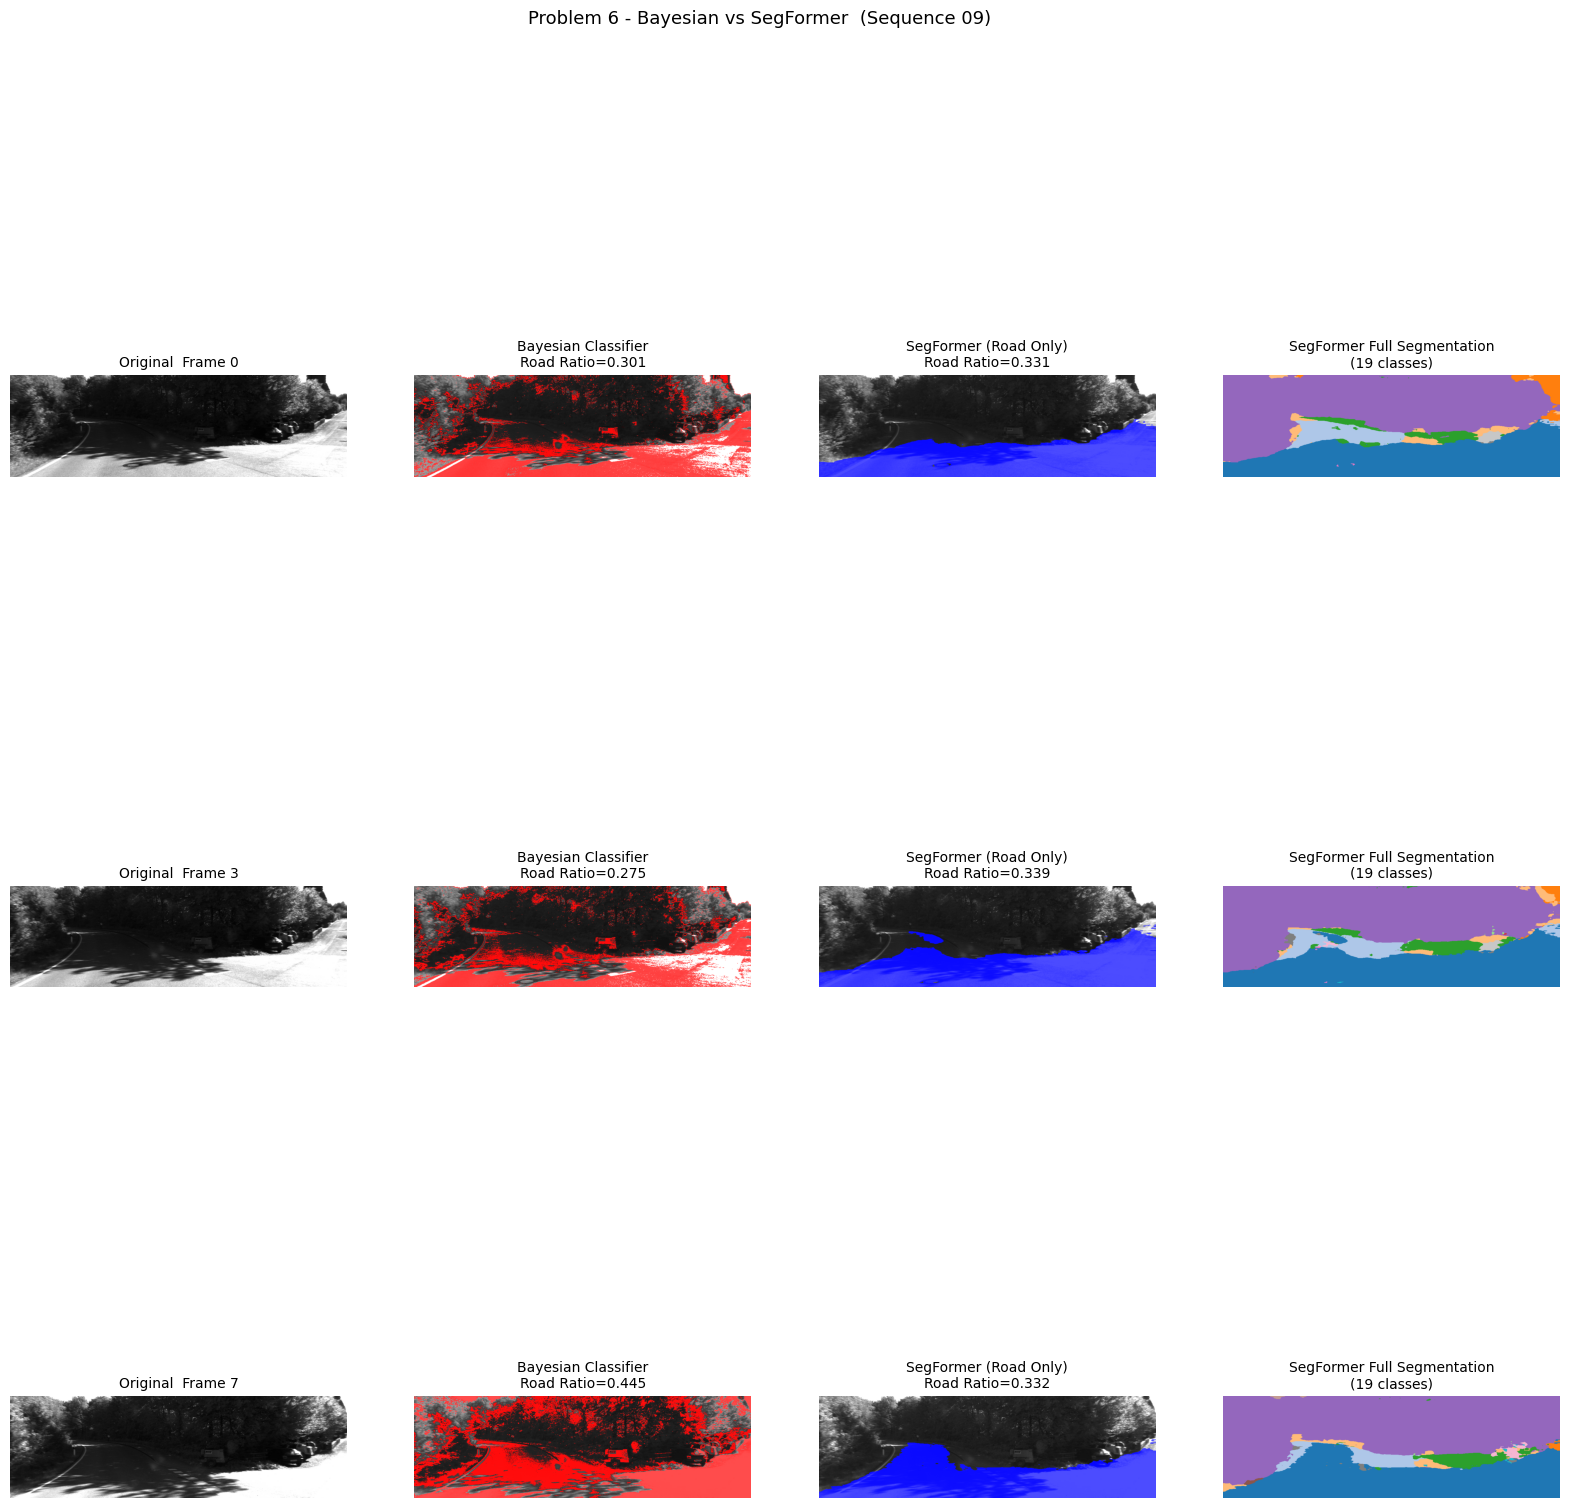


Frame    Bayesian Ratio       SegFormer Ratio
-------------------------------------------------------
0        0.301                0.331  (diff=+0.030)
3        0.275                0.339  (diff=+0.063)
7        0.445                0.332  (diff=-0.113)


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path
import torch
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import torch.nn.functional as F
import os

os.makedirs("outputs", exist_ok=True)

# ── 경로 설정 ─────────────────────────────────────────────
IMAGE_DIR = "dataset/gray/sequences/09/image_0"
MASK_DIR  = "outputs/bayes_road_advanced"

# ── 1. SegFormer 로드 (HuggingFace 자동 다운로드) ─────────
# cityscapes 학습 모델 - 도로/차선 클래스 포함
print("SegFormer 모델 로드 중... (첫 실행 시 자동 다운로드 약 50MB)")
processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-512-1024"
)
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-512-1024"
)
model.eval()
print("로드 완료!")

# Cityscapes 클래스 정의
# 0=road, 1=sidewalk, 8=vegetation, 9=terrain, 17=car ...
CITYSCAPES_CLASSES = {
    0:  'road', 1:  'sidewalk', 2:  'building', 3:  'wall',
    4:  'fence', 5:  'pole', 6:  'traffic light', 7:  'traffic sign',
    8:  'vegetation', 9:  'terrain', 10: 'sky', 11: 'person',
    12: 'rider', 13: 'car', 14: 'truck', 15: 'bus',
    16: 'train', 17: 'motorcycle', 18: 'bicycle'
}
ROAD_CLASS = 0  # road

# ── 2. 추론 함수 ──────────────────────────────────────────
def segment_image(img_gray, processor, model):
    """grayscale → RGB 변환 후 SegFormer 추론"""
    img_rgb = Image.fromarray(img_gray).convert('RGB')
    inputs  = processor(images=img_rgb, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    # 원본 해상도로 업샘플링
    logits = outputs.logits  # (1, num_classes, H/4, W/4)
    upsampled = F.interpolate(logits,
                              size=img_gray.shape,
                              mode='bilinear',
                              align_corners=False)
    pred = upsampled.argmax(dim=1).squeeze().numpy()  # (H, W)
    return pred

def get_road_mask(pred, road_class=0):
    """road 클래스 마스크 추출"""
    return (pred == road_class).astype(np.uint8) * 255

# ── 3. 비교 프레임 선택 ───────────────────────────────────
img_files  = sorted(Path(IMAGE_DIR).glob("*.png"))
mask_stems = {f.stem.replace('mask_', ''): f
              for f in Path(MASK_DIR).glob("mask_*.png")}

sample_idxs = [0, 3, 7]
print(f"\n비교 프레임: {sample_idxs}")

# ── 4. 시각화 ─────────────────────────────────────────────
fig = plt.figure(figsize=(20, 6 * len(sample_idxs)))
gs  = gridspec.GridSpec(len(sample_idxs), 4, hspace=0.4, wspace=0.2)

results = []

for row, idx in enumerate(sample_idxs):
    if idx >= len(img_files):
        continue

    img_gray = np.array(Image.open(img_files[idx]))
    stem     = img_files[idx].stem
    print(f"처리 중: Frame {idx} ({stem})")

    # ── Bayesian 마스크 ──────────────────────────────────
    bayes_overlay = np.stack([img_gray]*3, axis=-1)
    bayes_ratio   = 0.0
    if stem in mask_stems:
        msk = np.array(Image.open(mask_stems[stem]).convert('L'))
        bayes_overlay[msk > 0, 0] = 255
        bayes_overlay[msk > 0, 1] = (bayes_overlay[msk>0, 1] * 0.3).astype(np.uint8)
        bayes_overlay[msk > 0, 2] = (bayes_overlay[msk>0, 2] * 0.3).astype(np.uint8)
        bayes_ratio = (msk > 0).sum() / msk.size

    # ── SegFormer 추론 ───────────────────────────────────
    pred      = segment_image(img_gray, processor, model)
    road_mask = get_road_mask(pred, ROAD_CLASS)
    seg_ratio = (road_mask > 0).sum() / road_mask.size

    # SegFormer overlay (파란색)
    seg_overlay = np.stack([img_gray]*3, axis=-1)
    seg_overlay[road_mask > 0, 0] = (seg_overlay[road_mask>0, 0] * 0.3).astype(np.uint8)
    seg_overlay[road_mask > 0, 1] = (seg_overlay[road_mask>0, 1] * 0.3).astype(np.uint8)
    seg_overlay[road_mask > 0, 2] = 255

    # 전체 segmentation 컬러맵
    seg_color = np.zeros((*pred.shape, 3), dtype=np.uint8)
    color_map = plt.cm.tab20(np.linspace(0, 1, 19))
    for cls_id in range(19):
        seg_color[pred == cls_id] = (color_map[cls_id][:3] * 255).astype(np.uint8)

    results.append({
        'frame': idx,
        'bayes_ratio': bayes_ratio,
        'seg_ratio': seg_ratio,
    })

    ## [열1] 원본
    ax1 = fig.add_subplot(gs[row, 0])
    ax1.imshow(img_gray, cmap='gray')
    ax1.set_title(f'Original  Frame {idx}', fontsize=10)
    ax1.axis('off')

    ## [열2] Bayesian
    ax2 = fig.add_subplot(gs[row, 1])
    ax2.imshow(bayes_overlay)
    ax2.set_title(f'Bayesian Classifier\nRoad Ratio={bayes_ratio:.3f}', fontsize=10)
    ax2.axis('off')

    ## [열3] SegFormer 도로 마스크
    ax3 = fig.add_subplot(gs[row, 2])
    ax3.imshow(seg_overlay)
    ax3.set_title(f'SegFormer (Road Only)\nRoad Ratio={seg_ratio:.3f}', fontsize=10)
    ax3.axis('off')

    ## [열4] SegFormer 전체 segmentation
    ax4 = fig.add_subplot(gs[row, 3])
    ax4.imshow(seg_color)
    ax4.set_title(f'SegFormer Full Segmentation\n(19 classes)', fontsize=10)
    ax4.axis('off')

plt.suptitle('Problem 6 - Bayesian vs SegFormer  (Sequence 09)',
             fontsize=13, y=1.01)
plt.savefig("outputs/problem6_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 5. 정량 비교 ──────────────────────────────────────────
print("\n" + "="*55)
print(f"{'Frame':<8} {'Bayesian Ratio':<20} {'SegFormer Ratio'}")
print("-"*55)
for r in results:
    diff = r['seg_ratio'] - r['bayes_ratio']
    print(f"{r['frame']:<8} {r['bayes_ratio']:<20.3f} "
          f"{r['seg_ratio']:.3f}  (diff={diff:+.3f})")